In [1]:
!pip install -q shap

In [2]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV

print("All libraries loaded.")

All libraries loaded.


In [3]:
df = pd.read_csv('/kaggle/input/datasets/maryamrafaqat/data-engineered/data_engineered.csv')

TARGET = 'SeriousDlqin2yrs'
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Fill NaN
X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scale = (y_train == 0).sum() / (y_train == 1).sum()

# Train LightGBM (our best model)
model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=scale,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

model.fit(X_train, y_train)
print("LightGBM trained successfully.")
print(f"Features: {X_train.shape[1]}")
print(f"Train size: {X_train.shape[0]:,}")

LightGBM trained successfully.
Features: 21
Train size: 120,000


In [4]:
# Sample 2000 rows for speed
X_sample = X_test.sample(2000, random_state=42).reset_index(drop=True)
y_sample = y_test.iloc[:2000].reset_index(drop=True)

# TreeExplainer works with LightGBM
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# LightGBM returns list [class0, class1] — we want class 1 (default)
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

print("SHAP values computed.")
print(f"Shape: {shap_vals.shape}  (2000 users × {X_sample.shape[1]} features)")

SHAP values computed.
Shape: (2000, 21)  (2000 users × 21 features)


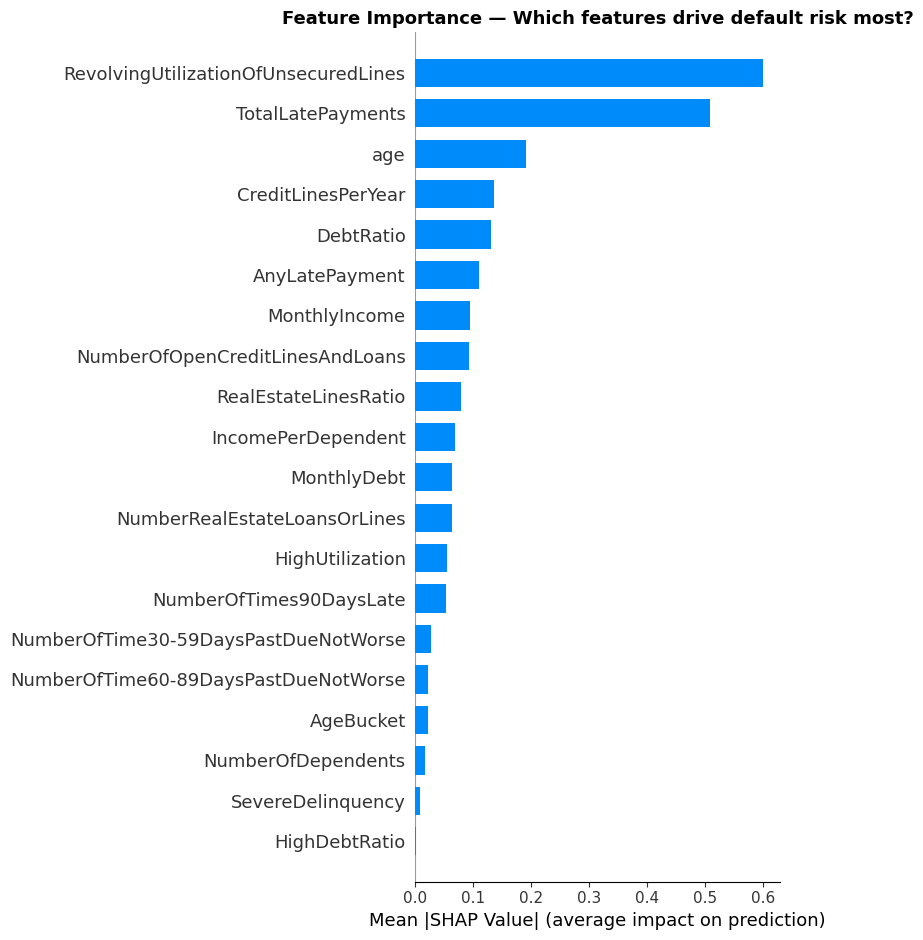


Top 10 Most Important Features:
   1. RevolvingUtilizationOfUnsecuredLines: 0.5992
   2. TotalLatePayments                  : 0.5092
   3. age                                : 0.1910
   4. CreditLinesPerYear                 : 0.1355
   5. DebtRatio                          : 0.1301
   6. AnyLatePayment                     : 0.1100
   7. MonthlyIncome                      : 0.0935
   8. NumberOfOpenCreditLinesAndLoans    : 0.0926
   9. RealEstateLinesRatio               : 0.0787
  10. IncomePerDependent                 : 0.0681


In [5]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_vals, X_sample,
    plot_type='bar',
    show=False
)
plt.title('Feature Importance — Which features drive default risk most?',
          fontsize=13, fontweight='bold')
plt.xlabel('Mean |SHAP Value| (average impact on prediction)')
plt.tight_layout()
plt.show()

# Also print top 5 as text
mean_shap = pd.Series(
    np.abs(shap_vals).mean(axis=0),
    index=X_sample.columns
).sort_values(ascending=False)

print("\nTop 10 Most Important Features:")
print("=" * 45)
for i, (feat, val) in enumerate(mean_shap.head(10).items(), 1):
    print(f"  {i:2d}. {feat:35s}: {val:.4f}")

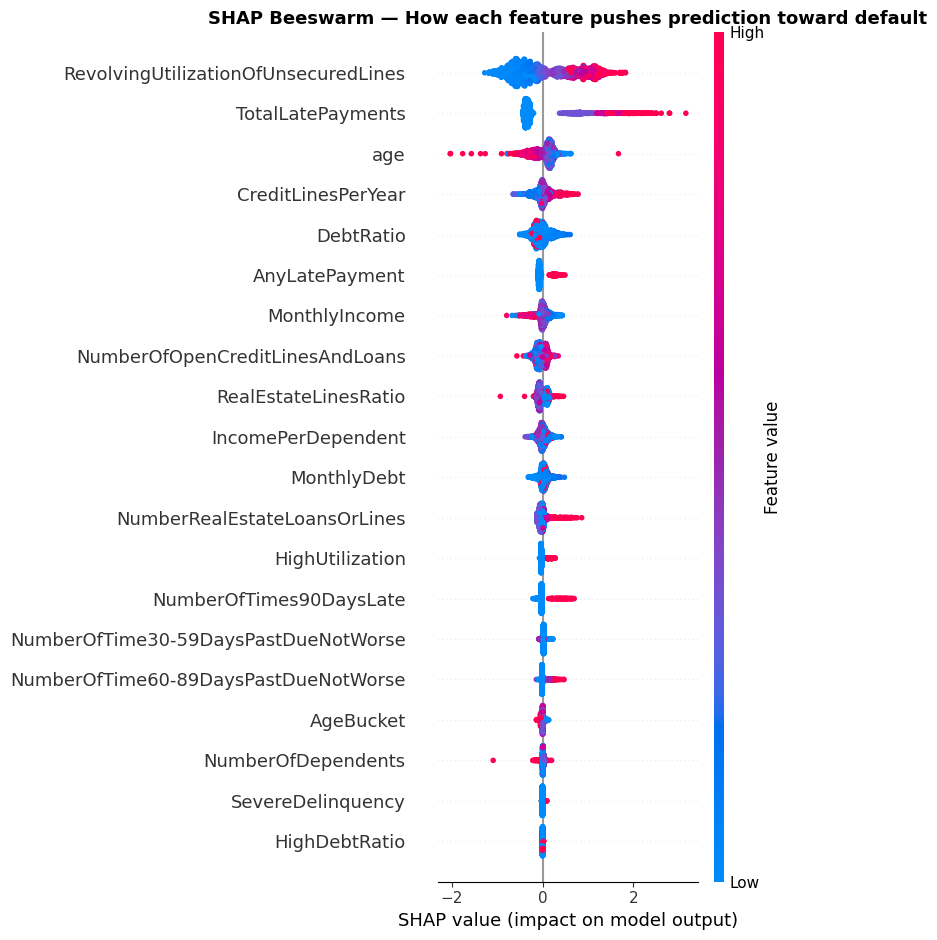


How to read this plot:
  Each dot    = one user
  Red dot     = user has HIGH value for that feature
  Blue dot    = user has LOW value for that feature
  Right side  = pushes toward DEFAULT (increases risk)
  Left side   = pushes toward REPAY (decreases risk)



In [6]:
plt.figure(figsize=(11, 8))
shap.summary_plot(
    shap_vals, X_sample,
    show=False
)
plt.title('SHAP Beeswarm — How each feature pushes prediction toward default',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
How to read this plot:
  Each dot    = one user
  Red dot     = user has HIGH value for that feature
  Blue dot    = user has LOW value for that feature
  Right side  = pushes toward DEFAULT (increases risk)
  Left side   = pushes toward REPAY (decreases risk)
""")

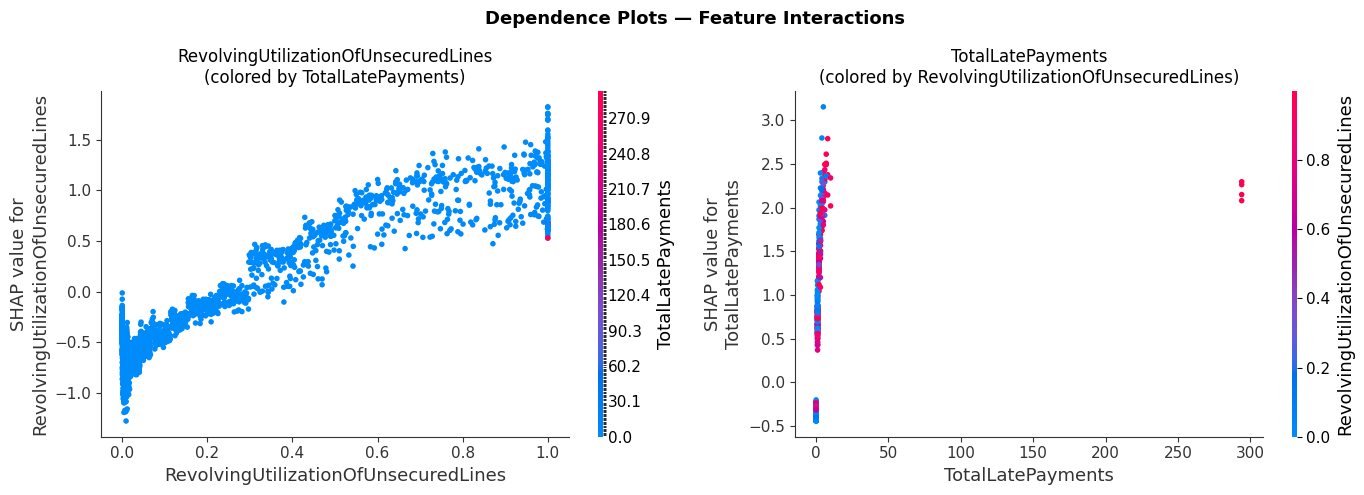


Key insight: As 'RevolvingUtilizationOfUnsecuredLines' increases,
default risk increases — especially when 'TotalLatePayments' is also high.


In [7]:
top_feature = mean_shap.index[0]
second_feature = mean_shap.index[1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dependence Plots — Feature Interactions', fontsize=13, fontweight='bold')

# Plot 1: Top feature
shap.dependence_plot(
    top_feature, shap_vals, X_sample,
    interaction_index=second_feature,
    ax=axes[0], show=False
)
axes[0].set_title(f'{top_feature}\n(colored by {second_feature})')

# Plot 2: Second feature
shap.dependence_plot(
    second_feature, shap_vals, X_sample,
    interaction_index=top_feature,
    ax=axes[1], show=False
)
axes[1].set_title(f'{second_feature}\n(colored by {top_feature})')

plt.tight_layout()
plt.show()

print(f"\nKey insight: As '{top_feature}' increases,")
print(f"default risk increases — especially when '{second_feature}' is also high.")

In [8]:
# Find one high-risk and one low-risk user
probs = model.predict_proba(X_sample)[:, 1]

high_risk_idx = probs.argmax()
low_risk_idx  = probs.argmin()

high_prob = probs[high_risk_idx]
low_prob  = probs[low_risk_idx]

print(f"High risk user #{high_risk_idx}: predicted default prob = {high_prob:.1%}")
print(f"Low risk  user #{low_risk_idx}:  predicted default prob = {low_prob:.1%}")
print(f"Actual labels: {y_sample.iloc[high_risk_idx]} vs {y_sample.iloc[low_risk_idx]}")

High risk user #1884: predicted default prob = 98.3%
Low risk  user #1678:  predicted default prob = 0.8%
Actual labels: 0 vs 0


=== HIGH RISK USER (prob=98.3%) ===


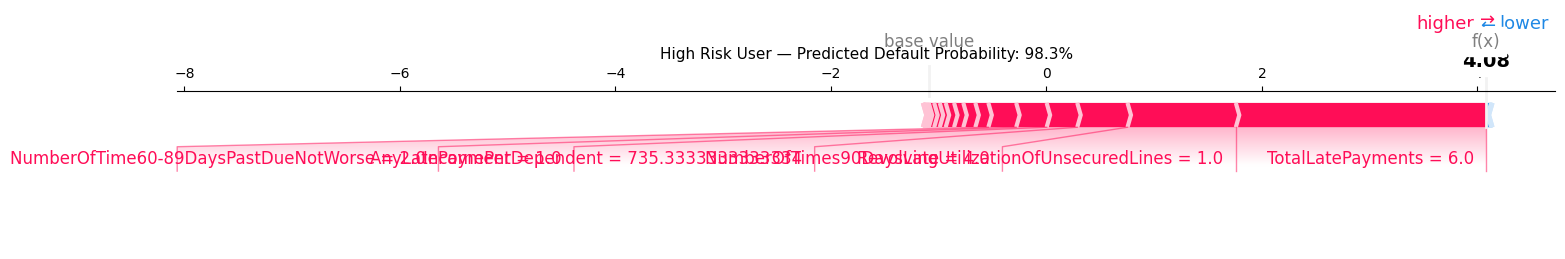

In [9]:
# Explain HIGH RISK user
print(f"=== HIGH RISK USER (prob={high_prob:.1%}) ===")

shap.force_plot(
    explainer.expected_value[1] if isinstance(explainer.expected_value, list)
    else explainer.expected_value,
    shap_vals[high_risk_idx],
    X_sample.iloc[high_risk_idx],
    matplotlib=True,
    show=False,
    figsize=(16, 3)
)
plt.title(f'High Risk User — Predicted Default Probability: {high_prob:.1%}',
          fontsize=11)
plt.tight_layout()
plt.show()

=== LOW RISK USER (prob=0.8%) ===


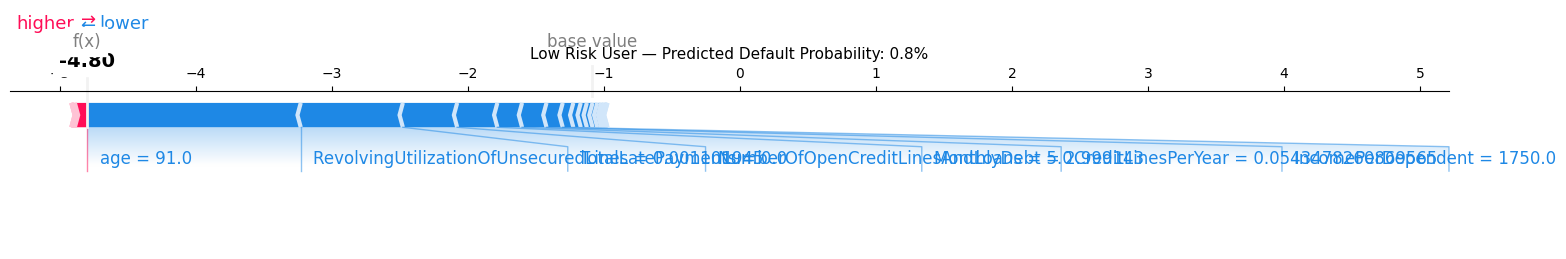

In [10]:
# Explain LOW RISK user
print(f"=== LOW RISK USER (prob={low_prob:.1%}) ===")

shap.force_plot(
    explainer.expected_value[1] if isinstance(explainer.expected_value, list)
    else explainer.expected_value,
    shap_vals[low_risk_idx],
    X_sample.iloc[low_risk_idx],
    matplotlib=True,
    show=False,
    figsize=(16, 3)
)
plt.title(f'Low Risk User — Predicted Default Probability: {low_prob:.1%}',
          fontsize=11)
plt.tight_layout()
plt.show()

In [11]:
# Clean summary table of top features + their direction
print("=" * 65)
print("   FEATURE IMPACT SUMMARY — LightGBM Credit Risk Model")
print("=" * 65)

for feat in mean_shap.head(10).index:
    feat_shap  = shap_vals[:, X_sample.columns.get_loc(feat)]
    feat_vals  = X_sample[feat]

    # Correlation between feature value and SHAP value
    direction = "↑ Higher value = MORE default risk" \
                if np.corrcoef(feat_vals, feat_shap)[0,1] > 0 \
                else "↓ Higher value = LESS default risk"

    importance = mean_shap[feat]
    print(f"\n  {feat}")
    print(f"    Importance : {importance:.4f}")
    print(f"    Direction  : {direction}")

print("\n" + "=" * 65)

   FEATURE IMPACT SUMMARY — LightGBM Credit Risk Model

  RevolvingUtilizationOfUnsecuredLines
    Importance : 0.5992
    Direction  : ↑ Higher value = MORE default risk

  TotalLatePayments
    Importance : 0.5092
    Direction  : ↑ Higher value = MORE default risk

  age
    Importance : 0.1910
    Direction  : ↓ Higher value = LESS default risk

  CreditLinesPerYear
    Importance : 0.1355
    Direction  : ↑ Higher value = MORE default risk

  DebtRatio
    Importance : 0.1301
    Direction  : ↓ Higher value = LESS default risk

  AnyLatePayment
    Importance : 0.1100
    Direction  : ↑ Higher value = MORE default risk

  MonthlyIncome
    Importance : 0.0935
    Direction  : ↓ Higher value = LESS default risk

  NumberOfOpenCreditLinesAndLoans
    Importance : 0.0926
    Direction  : ↑ Higher value = MORE default risk

  RealEstateLinesRatio
    Importance : 0.0787
    Direction  : ↓ Higher value = LESS default risk

  IncomePerDependent
    Importance : 0.0681
    Direction  : ↓